Librerias que se van a usar
from google.colab import drive
import os
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -la /content/drive/MyDrive/RIESGO/

total 2825
-rw------- 1 root root     763 Mar 12 00:39 label_encoders.joblib
-rw------- 1 root root    1167 Mar 12 00:46 minmax_scaler.joblib
-rw------- 1 root root    1615 Mar 12 00:46 pca_model.joblib
-rw------- 1 root root 2887904 Mar 10 23:43 riesgo.xlsx


In [4]:
ruta = "/content/drive/MyDrive/RIESGO"

In [5]:
%cd /content/drive/MyDrive/RIESGO

/content/drive/MyDrive/RIESGO


In [6]:
import os

os.listdir(ruta)

['riesgo.xlsx',
 'label_encoders.joblib',
 'pca_model.joblib',
 'minmax_scaler.joblib']

In [7]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/RIESGO/riesgo.xlsx")
df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,CUS_0x1000,Alistair Barrf,17.375,913-74-1218,Lawyer,30625.94,2706.161667,6.0,5.0,27,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,CUS_0x1009,Arunah,25.750,063-67-6938,Mechanic,52312.68,4250.390000,6.0,5.0,17,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,CUS_0x100b,Shirboni,18.500,238-62-0395,Media_Manager,113781.39,9549.782500,1.0,4.0,1,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,CUS_0x1011,Schneyerh,43.875,793-05-8223,Doctor,58918.47,5208.872500,3.0,3.0,17,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,CUS_0x1013,Cameront,43.750,930-49-9615,Mechanic,98620.98,7962.415000,3.0,3.0,6,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               12500 non-null  object 
 1   Name                      12500 non-null  object 
 2   Age                       12500 non-null  float64
 3   SSN                       12500 non-null  object 
 4   Occupation                12500 non-null  object 
 5   Annual_Income             12500 non-null  float64
 6   Monthly_Inhand_Salary     12500 non-null  float64
 7   Num_Bank_Accounts         12500 non-null  float64
 8   Num_Credit_Card           12500 non-null  float64
 9   Interest_Rate             12500 non-null  int64  
 10  Num_of_Loan               12500 non-null  int64  
 11  Type_of_Loan              11074 non-null  object 
 12  Delay_from_due_date       12500 non-null  float64
 13  Num_of_Delayed_Payment    12500 non-null  float64
 14  Change

In [9]:
print(df.isnull().sum())

Customer_ID                    0
Name                           0
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                1426
Delay_from_due_date            0
Num_of_Delayed_Payment         0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age             0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
dtype: int64


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,12500.0,33.311294,10.760177,14.000000,24.415179,33.000000,41.750000,56.000000
Annual_Income,12500.0,50505.123449,38300.762656,7005.930000,19342.972500,36999.705000,71683.470000,179987.280000
Monthly_Inhand_Salary,12500.0,4198.468568,3187.142979,303.645417,1625.744479,3097.016667,5961.664375,15204.633333
Num_Bank_Accounts,12500.0,5.368828,2.592493,0.000000,3.000000,5.375000,7.000000,10.500000
Num_Credit_Card,12500.0,5.533620,2.066040,0.500000,4.000000,5.000000,7.000000,10.875000
Interest_Rate,12500.0,14.532080,8.741636,1.000000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,12500.0,3.532880,2.446442,0.000000,2.000000,3.000000,5.000000,9.000000
Delay_from_due_date,12500.0,21.068780,14.772965,-2.000000,9.875000,17.875000,28.000000,63.250000
Num_of_Delayed_Payment,12500.0,13.338642,6.153148,0.000000,9.000000,13.750000,18.175000,26.375000
Changed_Credit_Limit,12500.0,10.465068,6.445141,0.500000,5.493750,9.370000,14.656250,31.115000


In [11]:
print(df.dtypes)

Customer_ID                  object
Name                         object
Age                         float64
SSN                          object
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate                 int64
Num_of_Loan                   int64
Type_of_Loan                 object
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                  int64
dtype: object


In [12]:
print(df.columns)

Index(['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')


In [13]:
# Eliminamos columnas que no aportan valor al modelo de predicción de riesgo crediticio

df.drop(
    columns=[
        "Customer_ID",  # Identificador único del cliente, no aporta información predictiva
        "Name",         # Nombre del cliente, dato personal irrelevante para el modelo
        "SSN",          # Número de seguridad social, información sensible y no útil para predicción
        "Type_of_Loan"  # Tipo de préstamo, se elimina si no se usará como variable explicativa
    ],
    axis=1,      # axis=1 indica que la operación se realiza sobre columnas (axis=0 sería para filas)
    inplace=True # modifica directamente el DataFrame original sin necesidad de reasignarlo a df
)

# Verificamos las columnas restantes en el dataset
df.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [14]:
# Eliminamos todas las filas donde la columna Credit_Score tenga valores nulos (NaN)

df.dropna(
    subset=["Credit_Score"],  # solo revisa la columna Credit_Score
    inplace=True              # modifica directamente el DataFrame original
)

# Restablecemos el índice del DataFrame después de eliminar filas
df.reset_index(
    drop=True,   # elimina el índice anterior en lugar de guardarlo como columna
    inplace=True # aplica el cambio directamente al DataFrame
)


# Verificamos que ya no existan valores nulos en esa columna
df["Credit_Score"].isnull().sum()

# Verificamos el resultado
df.head()


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,17.375,Lawyer,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,...,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,High_spent_Medium_value_payments,335.375341,0
1,25.750,Mechanic,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,...,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,High_spent_Medium_value_payments,428.743155,1
2,18.500,Media_Manager,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,...,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,High_spent_Large_value_payments,781.229776,0
3,43.875,Doctor,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,...,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,Low_spent_Medium_value_payments,332.642837,1
4,43.750,Mechanic,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,...,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,High_spent_Medium_value_payments,472.781009,1


In [15]:
# Seleccionamos únicamente las columnas cuyo tipo de dato es 'object' (texto)
columnas_object = df.select_dtypes(include=['object'])

# Mostramos las primeras filas de esas columnas
columnas_object.head()

,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
0,Lawyer,Bad,Yes,High_spent_Medium_value_payments
1,Mechanic,Standard,Yes,High_spent_Medium_value_payments
2,Media_Manager,Good,No,High_spent_Large_value_payments
3,Doctor,Standard,Yes,Low_spent_Medium_value_payments
4,Mechanic,Good,No,High_spent_Medium_value_payments


In [16]:
# Recorremos cada columna y mostramos la frecuencia de sus valores
for col in columnas_object:
    print(f"\nFrecuencia de valores para la columna: {col}")
    print(df[col].value_counts())


Frecuencia de valores para la columna: Occupation
Occupation
Lawyer           887
Engineer         858
Architect        853
Mechanic         847
Scientist        843
Accountant       843
Media_Manager    840
Developer        840
Teacher          834
Entrepreneur     831
Doctor           821
Journalist       817
Manager          804
Musician         794
Writer           788
Name: count, dtype: int64

Frecuencia de valores para la columna: Credit_Mix
Credit_Mix
Standard    5731
Good        3798
Bad         2971
Name: count, dtype: int64

Frecuencia de valores para la columna: Payment_of_Min_Amount
Payment_of_Min_Amount
Yes    7360
No     5031
NM      109
Name: count, dtype: int64

Frecuencia de valores para la columna: Payment_Behaviour
Payment_Behaviour
Low_spent_Small_value_payments      3860
High_spent_Medium_value_payments    3086
High_spent_Large_value_payments     2726
Low_spent_Medium_value_payments     1136
High_spent_Small_value_payments      972
Low_spent_Large_value_payments 

In [17]:
# Calcular la cardinalidad de la columna Credit_Mix
cardinalidad = df["Credit_Mix"].nunique()

print("La cardinalidad de la columna Credit_Mix es:", cardinalidad)

La cardinalidad de la columna Credit_Mix es: 3


In [18]:
# Mostrar los valores únicos de la columna
df["Credit_Mix"].unique()

array(['Bad', 'Standard', 'Good'], dtype=object)

# Vamos a eliminar la ocupacion y el comportamiento del pago inicialmente porque tiene una cardinalidad alta, pero basicamente es para agilizar el ejercicio.

In [19]:
# Eliminamos las columnas Occupation y Payment_Behaviour del DataFrame
df.drop(
    columns=["Occupation", "Payment_Behaviour"],  # columnas que queremos eliminar
    inplace=True, # aplica el cambio directamente sobre el DataFrame df
    axis = 1
)

# Verificamos las columnas restantes
df.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Score'],
      dtype='object')

In [20]:
# Mostrar los 10 primeros valores de la columna Credit_Score
df["Credit_Score"].head(10)

,Credit_Score
0,0
1,1
2,0
3,1
4,1
5,2
6,0
7,1
8,2
9,1


In [21]:
# Mostrar los valores únicos de la columna Credit_Score
df["Credit_Score"].unique()

array([0, 1, 2])

In [22]:
# Creamos la matriz de características (features)
# Eliminamos la columna Credit_Score porque será la variable objetivo (target)

X = df.drop(columns=["Credit_Score"])
y= df["Credit_Score"]

# Verificamos las primeras filas de los features
X.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,10.875000,Bad,1562.91,33.477546,10.458333,Yes,42.941090,158.549735,335.375341
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,3.000000,Standard,202.68,29.839984,30.714286,Yes,108.366467,146.679378,428.743155
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,1.857143,Good,1030.20,34.841449,15.571429,No,0.000000,505.386526,781.229776
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,7.000000,Standard,473.14,27.655897,15.541667,Yes,123.434939,311.060914,332.642837
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,3.000000,Good,1233.51,31.933940,17.535714,No,228.018084,355.442408,472.781009


In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# 1️⃣ Obtener las columnas categóricas (tipo object)
categorical_cols = X.select_dtypes(include=['object']).columns

# Diccionario para guardar los encoders de cada columna
encoders = {}

# 2️⃣ Aplicar LabelEncoder a cada columna categórica
for col in categorical_cols:
    le = LabelEncoder()                 # Crear encoder
    X[col] = le.fit_transform(X[col])   # Ajustar y transformar la columna
    encoders[col] = le                  # Guardar el encoder en el diccionario

# 3️⃣ Guardar los encoders para reutilizarlos después
joblib.dump(encoders, "label_encoders.joblib")

# 4️⃣ Verificar resultado
X.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,17.375,30625.94,2706.161667,6.0,5.0,27,2,62.25,25.000000,1.880000,10.875000,0,1562.91,33.477546,10.458333,2,42.941090,158.549735,335.375341
1,25.750,52312.68,4250.390000,6.0,5.0,17,4,7.25,17.857143,9.730000,3.000000,2,202.68,29.839984,30.714286,2,108.366467,146.679378,428.743155
2,18.500,113781.39,9549.782500,1.0,4.0,1,0,13.50,7.375000,10.911429,1.857143,1,1030.20,34.841449,15.571429,1,0.000000,505.386526,781.229776
3,43.875,58918.47,5208.872500,3.0,3.0,17,3,27.25,14.500000,14.170000,7.000000,2,473.14,27.655897,15.541667,2,123.434939,311.060914,332.642837
4,43.750,98620.98,7962.415000,3.0,3.0,6,3,12.50,8.428571,1.705000,3.000000,1,1233.51,31.933940,17.535714,1,228.018084,355.442408,472.781009


In [24]:
ls -la

total 2825
-rw------- 1 root root     763 Mar 17 21:40 label_encoders.joblib
-rw------- 1 root root    1167 Mar 12 00:46 minmax_scaler.joblib
-rw------- 1 root root    1615 Mar 12 00:46 pca_model.joblib
-rw------- 1 root root 2887904 Mar 10 23:43 riesgo.xlsx


In [25]:
# Mostrar los nombres de los features codificados con LabelEncoder
print("Features usados en label_encoders:", list(encoders.keys()))

# Mostrar las etiquetas originales aprendidas por cada encoder
for feature, encoder in encoders.items():
	print(f"\nEtiquetas para '{feature}':")
	print(encoder.classes_)

Features usados en label_encoders: ['Credit_Mix', 'Payment_of_Min_Amount']

Etiquetas para 'Credit_Mix':
['Bad' 'Good' 'Standard']

Etiquetas para 'Payment_of_Min_Amount':
['NM' 'No' 'Yes']


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       12500 non-null  float64
 1   Annual_Income             12500 non-null  float64
 2   Monthly_Inhand_Salary     12500 non-null  float64
 3   Num_Bank_Accounts         12500 non-null  float64
 4   Num_Credit_Card           12500 non-null  float64
 5   Interest_Rate             12500 non-null  int64  
 6   Num_of_Loan               12500 non-null  int64  
 7   Delay_from_due_date       12500 non-null  float64
 8   Num_of_Delayed_Payment    12500 non-null  float64
 9   Changed_Credit_Limit      12500 non-null  float64
 10  Num_Credit_Inquiries      12500 non-null  float64
 11  Credit_Mix                12500 non-null  int64  
 12  Outstanding_Debt          12500 non-null  float64
 13  Credit_Utilization_Ratio  12500 non-null  float64
 14  Credit

In [27]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1️⃣ Crear el selector SelectKBest con f_classif (para clasificación)
selector = SelectKBest(score_func=f_classif, k=5)

# 2️⃣ Ajustar el selector a los datos de entrenamiento
selector.fit(X, y)

# 3️⃣ Obtener los índices de las mejores 10 features
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]

# 4️⃣ Mostrar las mejores 10 features ordenadas por score
feature_scores = selector.scores_[selected_indices]
features_ranking = pd.DataFrame({
    'Feature': selected_features,
    'Score': feature_scores
}).sort_values(by='Score', ascending=False)

print("Mejores 10 features:")
print(features_ranking)

# 5️⃣ Transformar X_train y X_test usando las mejores features
X_selected = selector.transform(X)


# 6️⃣ Convertir a DataFrame para mantener nombres de columnas
X_selected = pd.DataFrame(X_selected, columns=selected_features)


print("\nForma de X_train después de SelectKBest:", X_selected.shape)

Mejores 10 features:
                 Feature        Score
1          Interest_Rate  2483.771502
3   Num_Credit_Inquiries  2148.352205
4  Payment_of_Min_Amount  2056.649897
2    Delay_from_due_date  1881.042992
0        Num_Credit_Card  1560.202491

Forma de X_train después de SelectKBest: (12500, 5)


In [28]:
from tensorflow.keras.utils import to_categorical


# Aplicamos one-hot encoding usando to_categorical con 3 clases
y = to_categorical(df['Credit_Score'],num_classes=3)

# Verificamos el resultado
y[:10]

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [29]:
from sklearn.decomposition import PCA

# 1️⃣ Crear el objeto PCA con 5 componentes
pca = PCA(n_components=5)

# 2️⃣ Ajustar PCA a X_selected y transformar los datos
X_pca = pca.fit_transform(X_selected)

# 3️⃣ Convertir el resultado a DataFrame para mejor visualización
X_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(5)]
)

# 4️⃣ Mostrar los primeros datos después de PCA
print("Datos después de PCA (5 componentes):")
print(X_pca.head())

# 5️⃣ Varianza explicada por cada componente
print("\n\nVarianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

# 6️⃣ Varianza acumulada
print("\nVarianza acumulada:")
print(pca.explained_variance_ratio_.cumsum())

# 7️⃣ Porcentaje total de varianza explicada
print(f"\nVarianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# 8️⃣ Componentes principales (loadings)
print("\n\nComponentes principales (loadings):")
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(5)],
    index=X_selected.columns
)
print(loadings)

Datos después de PCA (5 componentes):
         PC1       PC2       PC3       PC4       PC5
0  42.841915 -5.675909 -0.831502 -3.065456 -0.176382
1 -11.915142  7.538465 -2.461407  0.227451  0.572507
2 -12.939371 -9.539055 -0.199322 -0.064571 -0.117114
3   6.575612 -0.373786 -0.192403 -2.977863  0.315830
4 -11.737735 -4.544697 -0.429629 -1.424198 -0.247337


Varianza explicada por cada componente:
[8.26243580e-01 1.42361647e-01 2.18935950e-02 9.05414872e-03
 4.47029334e-04]

Varianza acumulada:
[0.82624358 0.96860523 0.99049882 0.99955297 1.        ]

Varianza total explicada: 100.00%


Componentes principales (loadings):
                            PC1       PC2       PC3       PC4       PC5
Num_Credit_Card        0.068572  0.058023  0.151659  0.984311 -0.007968
Interest_Rate          0.399977  0.881674 -0.246246 -0.042028 -0.016293
Delay_from_due_date    0.901351 -0.427670 -0.062201 -0.028025 -0.003152
Num_Credit_Inquiries   0.150218  0.189297  0.954085 -0.169050 -0.052393
Payment_of_Mi

In [30]:
# Persistencia del modelo PCA ya entrenado
archivo_pca = os.path.join(ruta, "pca_model.joblib")
joblib.dump(pca, archivo_pca)

print(f"Modelo PCA guardado en: {archivo_pca}")

Modelo PCA guardado en: /content/drive/MyDrive/RIESGO/pca_model.joblib


In [31]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# 1️⃣ Crear el escalador MinMax (escala los datos entre 0 y 1)
scaler = MinMaxScaler(feature_range=(0, 1))

# 2️⃣ Ajustar el escalador a los datos y transformar X
X_scaled = scaler.fit_transform(X_pca)

# 3️⃣ Convertir el resultado nuevamente en DataFrame para mantener nombres de columnas
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X_pca.columns)

# 4️⃣ Guardar el escalador para reutilizarlo después
joblib.dump(scaler, "minmax_scaler.joblib")

# 5️⃣ Verificar los primeros datos escalados
X_scaled.head()

,PC1,PC2,PC3,PC4,PC5
0,0.953982,0.263737,0.378008,0.143065,0.653811
1,0.202303,0.581526,0.280697,0.518793,0.884099
2,0.188243,0.170833,0.415751,0.485473,0.672036
3,0.456135,0.391246,0.416164,0.153060,0.805169
4,0.204738,0.290941,0.402001,0.330337,0.631992


In [32]:
# Ver cuántos datos hay en X (features)
print("Datos en X:", X_scaled.shape)

# Ver cuántos datos hay en y (variable objetivo)
print("Datos en y:", y.shape)

Datos en X: (12500, 5)
Datos en y: (12500, 3)


In [33]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (85%) y prueba (15%)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, 
    y,
    test_size=0.15,   # 15% para prueba
    stratify=y,       # mantiene la misma proporción de clases en train y test
    random_state=42   # semilla para reproducibilidad
)

# Verificar tamaños de los conjuntos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10625, 5)
X_test: (1875, 5)
y_train: (10625, 3)
y_test: (1875, 3)


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

model = Sequential(name='modelo_secuencial')
model.add(Input(shape=(5,), name='input_layer'))           # X_train tiene 5 columnas
model.add(Dense(64, activation='relu', name='hidden1'))    # primera capa oculta
model.add(Dense(32, activation='relu', name='hidden2'))    # segunda capa oculta
model.add(Dense(16, activation='relu', name='hidden3'))    # tercera capa oculta
model.add(Dense(3, activation='softmax', name='output_layer'))  # salida con 3 neuronas


# Compilar el modelo con optimizer Adam, loss categorical_crossentropy y métrica accuracy
model.compile(
    optimizer=Adam(learning_rate=0.001),           # Optimizador Adam con learning rate de 0.001
    loss='categorical_crossentropy',               # Función de pérdida para clasificación multiclase
    metrics=['accuracy']                           # Métrica de evaluación
)

model.summary()

Model: "modelo_secuencial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,043 (11.89 KB)

 Trainable params: 3,043 (11.89 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# entrenamiento del modelo usando los datos ya preparados
# 100 épocas y 15 % de los datos de entrenamiento como validación
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.15,
    verbose=1
)

Epoch 1/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6211 - loss: 0.8708 - val_accuracy: 0.6719 - val_loss: 0.7559
Epoch 2/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6813 - loss: 0.7406 - val_accuracy: 0.6863 - val_loss: 0.7258
Epoch 3/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6840 - loss: 0.7199 - val_accuracy: 0.6882 - val_loss: 0.7124
Epoch 4/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6885 - loss: 0.7075 - val_accuracy: 0.6857 - val_loss: 0.7178
Epoch 5/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6885 - loss: 0.7056 - val_accuracy: 0.6832 - val_loss: 0.7167
Epoch 6/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6886 - loss: 0.7015 - val_accuracy: 0.6920 - val_loss: 0.7178
Epoch 7/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6933 - loss: 0.6991 - val_accuracy: 0.6888 - val_loss: 0.7108
Epoch 8/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6935 - loss: 0.6949 - val_accu

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# hacemos la evaluación sobre el conjunto de prueba

# 1) métrica directa del modelo
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss en test: {loss:.4f}  -  Accuracy en test: {acc:.4f}")

# 2) obtener predicciones y comparar con las etiquetas reales
y_pred = model.predict(X_test)              # salidas softmax
y_pred_labels = y_pred.argmax(axis=1)       # clase con mayor probabilidad
y_true_labels = y_test.argmax(axis=1)


print("\nAccuracy (sklearn):",
    accuracy_score(y_true_labels, y_pred_labels))

print("\nReporte de clasificación:")
print(classification_report(y_true_labels, y_pred_labels,
                    target_names=["score0","score1","score2"]))

print("\nMatriz de confusión:")
print(confusion_matrix(y_true_labels, y_pred_labels))

Loss en test: 0.6993  -  Accuracy en test: 0.7003
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Accuracy (sklearn): 0.7002666666666667

Reporte de clasificación:
              precision    recall  f1-score   support

      score0       0.72      0.71      0.72       624
      score1       0.73      0.69      0.71       917
      score2       0.59      0.71      0.64       334

    accuracy                           0.70      1875
   macro avg       0.68      0.70      0.69      1875
weighted avg       0.70      0.70      0.70      1875


Matriz de confusión:
[[445 143  36]
 [159 632 126]
 [ 10  88 236]]


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


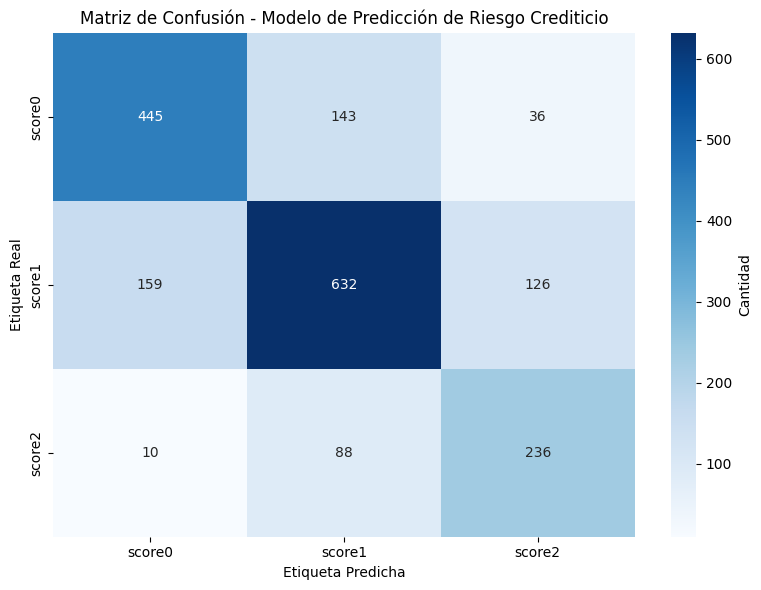

In [37]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Obtener predicciones
y_pred = model.predict(X_test)
y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

# Calcular la matriz de confusión
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Crear figura con tamaño apropiado
plt.figure(figsize=(8, 6))

# Crear heatmap con seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['score0', 'score1', 'score2'],
            yticklabels=['score0', 'score1', 'score2'],
            cbar_kws={'label': 'Cantidad'})

plt.title('Matriz de Confusión - Modelo de Predicción de Riesgo Crediticio')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

In [38]:
# persistir el modelo entrenado en disco con el formato nativo de Keras

# ruta donde se guardará el fichero
modelo_keras = os.path.join(ruta, "modelo_credito.keras")
model.save(modelo_keras)              # crea un directorio/archivo con la extensión .keras
print(f"Modelo Keras persistido en: {modelo_keras}")

# opcionalmente también se puede salvar en formato HDF5 (.h5)
modelo_h5 = os.path.join(ruta, "modelo_credito.keras")
model.save(modelo_h5)
print(f"Modelo en formato HDF5 guardado en: {modelo_h5}")

Modelo Keras persistido en: /content/drive/MyDrive/RIESGO/modelo_credito.keras
Modelo en formato HDF5 guardado en: /content/drive/MyDrive/RIESGO/modelo_credito.keras
